In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dummy_data = {
    "images": [
        # Vertical patterns
        [
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0],
            [0,0,0,1,1,0,0,0]
        ],

        [
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0],
            [0,0,1,1,0,0,0,0]
        ],

        [
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0],
            [0,0,0,0,1,1,0,0]
        ],

        # Horizontal patterns
        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ],

        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ],

        [
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0],
            [1,1,1,1,1,1,1,1],
            [1,1,1,1,1,1,1,1],
            [0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0]
        ]
    ],

    "labels": [0, 0, 0, 1, 1, 1]
}

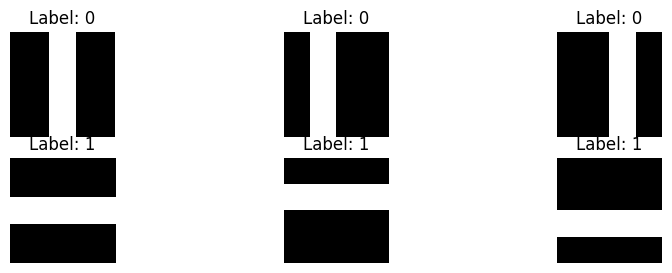

In [4]:
images = dummy_data['images']
labels = dummy_data['labels']

plt.figure(figsize=(10,3))

for i,image in enumerate(images):
    plt.subplot(2,3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
plt.show()

In [5]:
import numpy as np

X = np.array(dummy_data['images'], dtype='float32')
y = np.array(dummy_data['labels'])

X = X[..., np.newaxis]

print(X.shape)

(6, 8, 8, 1)


In [7]:
X = X.astype('float32')/255


In [11]:
# Encoder 
latend_dim = 2
encoder_input = keras.Input(shape=(8,8,1))
x = layers.Flatten()(encoder_input)
x = layers.Dense(32, activation='sigmoid')(x)

z_mean = layers.Dense(latend_dim, name='z_mean')(x)
z_log_var = layers.Dense(latend_dim, name='z_log_var')(x)

encoder = keras.Model(encoder_input, [z_mean, z_log_var], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 8, 8, 1)]    0           []                               
                                                                                                  
 flatten_2 (Flatten)            (None, 64)           0           ['input_3[0][0]']                
                                                                                                  
 dense_2 (Dense)                (None, 32)           2080        ['flatten_2[0][0]']              
                                                                                                  
 z_mean (Dense)                 (None, 2)            66          ['dense_2[0][0]']                
                                                                                            

In [15]:
def Sampling(args):
    z_mean,z_log_var = args 
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
    return z 
z = layers.Lambda(Sampling)([z_mean,z_log_var])

In [17]:
#decoder
decoder_input = keras.Input(shape=(latend_dim,))
x = layers.Dense(32, activation='relu')(decoder_input)
x = layers.Dense(8*8, activation='sigmoid')(x)
decoder_output = layers.Reshape((8,8,1))(x)

decoder = keras.Model(decoder_input,decoder_output, name='decoder')
decoder.summary()


Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 2)]               0         
                                                                 
 dense_5 (Dense)             (None, 32)                96        
                                                                 
 dense_6 (Dense)             (None, 64)                2112      
                                                                 
 reshape_1 (Reshape)         (None, 8, 8, 1)           0         
                                                                 
Total params: 2,208
Trainable params: 2,208
Non-trainable params: 0
_________________________________________________________________


In [19]:
output = decoder(z)
vae = keras.Model(encoder_input,output, name='vae')


In [24]:
vae.compile(optimizer='adam',loss='binary_crossentropy')

In [25]:
history = vae.fit(X,X, epochs=10, batch_size=3)

Epoch 1/10
2/2 [==============================] - 1s 4ms/step - loss: 0.6985
Epoch 2/10
2/2 [==============================] - 0s 3ms/step - loss: 0.6945
Epoch 3/10
2/2 [==============================] - 0s 3ms/step - loss: 0.6896
Epoch 4/10
2/2 [==============================] - 0s 4ms/step - loss: 0.6864
Epoch 5/10
2/2 [==============================] - 0s 3ms/step - loss: 0.6826
Epoch 6/10
2/2 [==============================] - 0s 4ms/step - loss: 0.6776
Epoch 7/10
2/2 [==============================] - 0s 5ms/step - loss: 0.6732
Epoch 8/10
2/2 [==============================] - 0s 2ms/step - loss: 0.6717
Epoch 9/10
2/2 [==============================] - 0s 20ms/step - loss: 0.6622
Epoch 10/10
2/2 [==============================] - 0s 7ms/step - loss: 0.6592


In [26]:
z_random = np.random.normal(
    size=(1, latend_dim)
)

print(z_random)

[[-1.14664381 -0.82697012]]


In [27]:
new_image = decoder.predict(z_random)

1/1 [==============================] - 0s 89ms/step


In [30]:
new_image.shape

(1, 8, 8, 1)

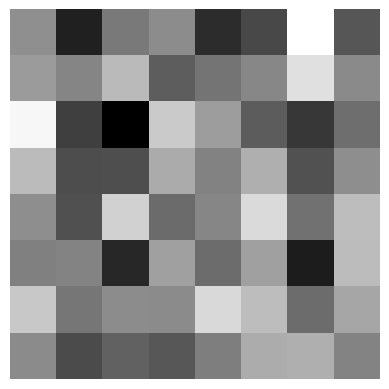

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(new_image[0, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()

# Numpy array 

In [31]:
X = np.random.randint(0,2, (100,8,8))

In [32]:
X = X.astype('float32')

X = X[...,np.newaxis]

# Dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    'catdog/train', image_
)

In [6]:
train_path = "catdog/train"
test_path = "catdog/test"

In [7]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(32, 32),
    batch_size=32,
    label_mode=None
)

Found 557 files belonging to 1 classes.


In [8]:
for images in train_ds.take(1):
    print(images.shape)

(32, 32, 32, 3)


In [10]:
train_ds = train_ds.map(lambda x: x/255.0)


In [14]:
for img in train_ds.take(1):
    print('Min:', tf.reduce_min(img).numpy())

Min: 0.0


In [17]:
x = tf.constant([5, 2, 8, 1, 9])

tf.reduce_min(x).numpy()

1